# DQN Stable-Baselines3 sur highway-v0
Comparaison equitable avec le DQN custom : memes hyperparametres, 1 seul environnement, training par episodes.

In [1]:
import os, json, datetime, math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import gymnasium as gym
import highway_env
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from shared_core_config import SHARED_CORE_ENV_ID, SHARED_CORE_CONFIG

## 01. Configuration

In [2]:
# --- Configuration alignee sur le DQN custom ---
SEEDS = [0, 1, 2]
NUM_EPISODES = 2_500          # meme que le custom
EVAL_EPISODES = 50
EVAL_SEED_OFFSET = 1_000     # meme que le custom
FAILURE_SEED_OFFSET = 9_000  # meme que le custom
FAILURE_EPISODES = 100

# Hyperparametres identiques au custom
HIDDEN_SIZE = 256
BATCH_SIZE = 32
GAMMA = 0.99
LR = 5e-4
BUFFER_SIZE = 15_000
LEARNING_STARTS = 200
TARGET_UPDATE = 50
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 5_000  # constante du decay exponentiel custom
GRAD_CLIP = 100

RUN_ID = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
SAVE_DIR = os.path.join("checkpoints_sb", f"run_{RUN_ID}")
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Save dir: {SAVE_DIR}")

Device: cuda
Save dir: checkpoints_sb\run_20260408-172848


## 02. Environnement

In [3]:
def make_env(seed=0):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode="rgb_array")
    env.unwrapped.configure(SHARED_CORE_CONFIG)
    env.reset(seed=seed)
    return env

## 03. Entrainement multi-seed
- 1 seul environnement (comme le custom)
- Epsilon exponentiel identique au custom
- Training par episodes (2500 episodes)
- 1 gradient step par step (comme le custom)

In [4]:
class TrainingTracker(BaseCallback):
    """Track per-episode metrics and enforce exponential epsilon + episode limit."""

    def __init__(self, num_episodes, eps_start, eps_end, eps_decay):
        super().__init__()
        self.num_episodes = num_episodes
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay

        self.episode_rewards = []
        self.episode_lengths = []
        self.episode_epsilons = []
        self._ep_reward = 0.0
        self._ep_length = 0
        self._ep_count = 0

    def _get_epsilon(self):
        return self.eps_end + (self.eps_start - self.eps_end) * math.exp(
            -self.num_timesteps / self.eps_decay
        )

    def _on_step(self):
        # Override SB3 epsilon with exponential decay
        self.model.exploration_rate = self._get_epsilon()

        self._ep_reward += self.locals["rewards"][0]
        self._ep_length += 1

        if self.locals["dones"][0]:
            self.episode_rewards.append(self._ep_reward)
            self.episode_lengths.append(self._ep_length)
            self.episode_epsilons.append(self.model.exploration_rate)
            self._ep_count += 1
            self._ep_reward = 0.0
            self._ep_length = 0

            if self._ep_count >= self.num_episodes:
                return False  # stop training

        return True


trained_models = {}
training_data = {}

for seed in SEEDS:
    print(f"\n{'='*50}")
    print(f"  Seed {seed}")
    print(f"{'='*50}")

    env = make_env(seed=seed)

    model = DQN(
        "MlpPolicy",
        env,
        learning_rate=LR,
        buffer_size=BUFFER_SIZE,
        learning_starts=LEARNING_STARTS,
        batch_size=BATCH_SIZE,
        gamma=GAMMA,
        target_update_interval=TARGET_UPDATE,
        train_freq=(4, "step"),       # collecte 4 steps avant de train (reduit l'overhead Python/CUDA)
        gradient_steps=4,             # 4 updates d'un coup -> meme ratio total qu'avant
        exploration_initial_eps=EPS_START,
        exploration_final_eps=EPS_END,
        exploration_fraction=1.0,     # on override avec le callback
        max_grad_norm=GRAD_CLIP,      # gradient clipping
        policy_kwargs=dict(net_arch=[HIDDEN_SIZE, HIDDEN_SIZE]),
        device=DEVICE,
        seed=seed,
        verbose=0,
    )

    tracker = TrainingTracker(NUM_EPISODES, EPS_START, EPS_END, EPS_DECAY)

    # timesteps large pour ne pas couper avant la fin des episodes
    model.learn(total_timesteps=NUM_EPISODES * 50, callback=tracker, progress_bar=True)

    model.save(os.path.join(SAVE_DIR, f"dqn_seed{seed}"))
    trained_models[seed] = model
    training_data[seed] = {
        "rewards": tracker.episode_rewards,
        "lengths": tracker.episode_lengths,
        "epsilons": tracker.episode_epsilons,
    }
    env.close()

    print(f"  {len(tracker.episode_rewards)} episodes, "
          f"{tracker.num_timesteps} steps")


  Seed 0


Output()

Output()

  2500 episodes, 39162 steps

  Seed 1


Output()

  2500 episodes, 34353 steps

  Seed 2


  2500 episodes, 38255 steps


## 04. Courbes d'entraînement

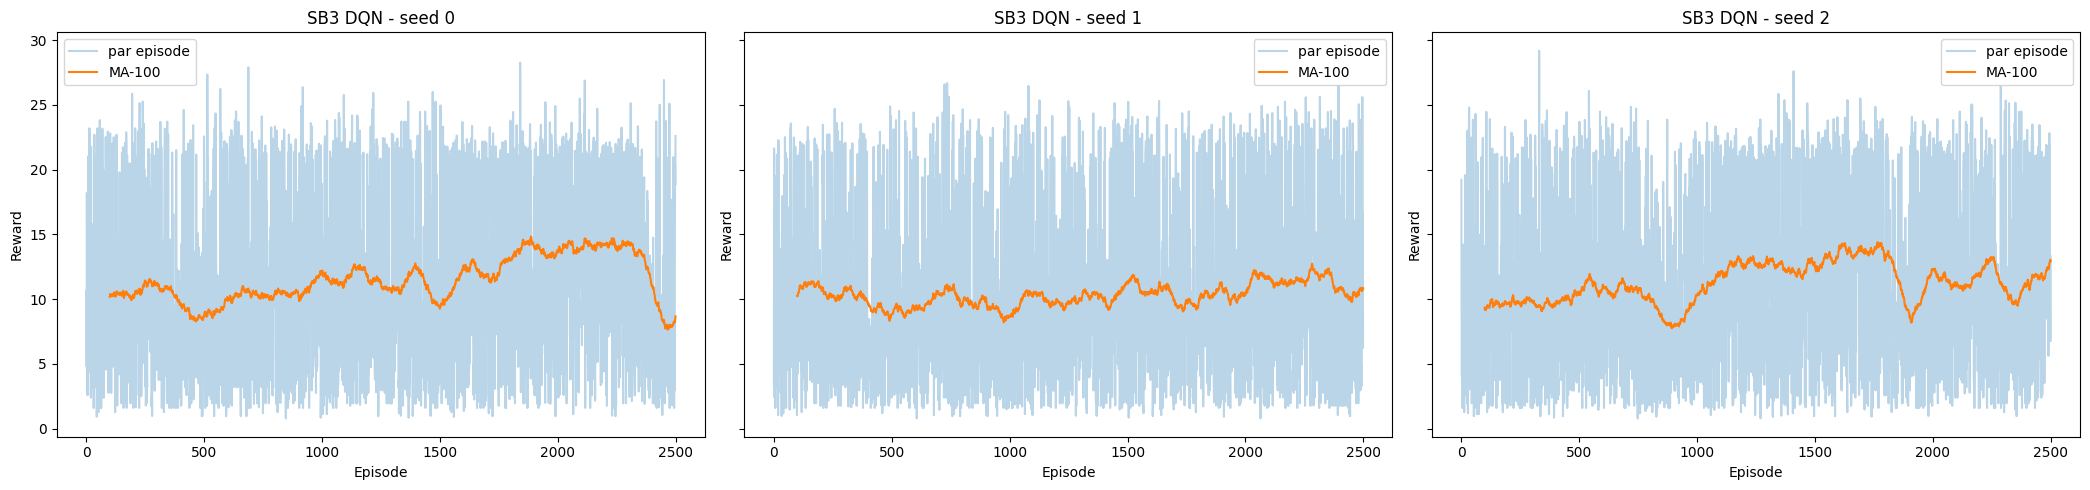

In [5]:
window = 100
fig, axes = plt.subplots(1, len(SEEDS), figsize=(7 * len(SEEDS), 5), sharey=True)
if len(SEEDS) == 1:
    axes = [axes]

for ax, seed in zip(axes, SEEDS):
    r = np.array(training_data[seed]["rewards"])
    ax.plot(r, alpha=0.3, label="par episode")
    if len(r) >= window:
        smooth = np.convolve(r, np.ones(window) / window, mode="valid")
        ax.plot(np.arange(window - 1, len(r)), smooth, label=f"MA-{window}")
    ax.set_title(f"SB3 DQN - seed {seed}")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward")
    ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "sb3_training_curves.png"), dpi=150)
plt.show()

## 04b. Courbe agregee multi-seed

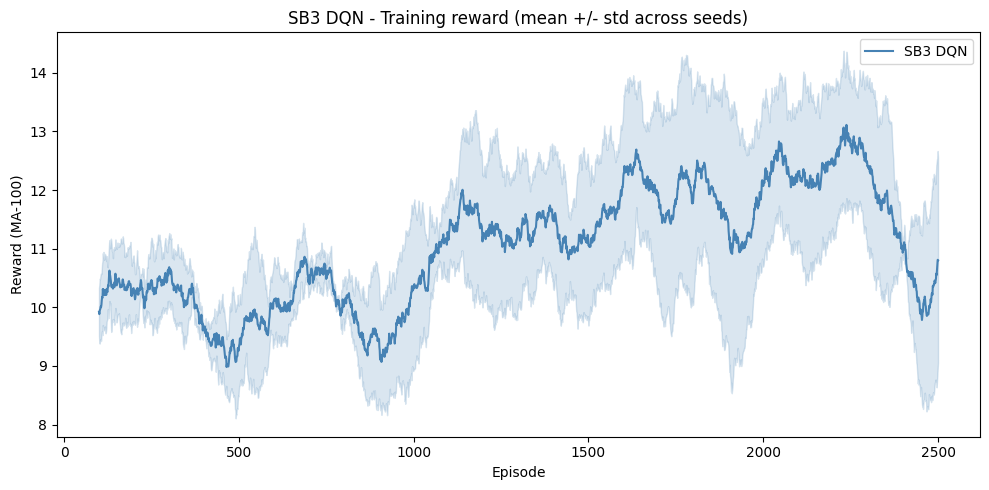

In [6]:
def plot_multi_seed(all_rewards, label="", window=100, ax=None, color=None):
    smoothed = []
    for rewards in all_rewards:
        t = np.array(rewards, dtype=np.float32)
        if len(t) >= window:
            s = np.convolve(t, np.ones(window) / window, mode="valid")
        else:
            s = t
        smoothed.append(s)

    min_len = min(len(s) for s in smoothed)
    arr = np.array([s[:min_len] for s in smoothed])
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)
    x = np.arange(min_len) + window

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))

    kw = dict(color=color) if color else {}
    ax.plot(x, mean, label=label, **kw)
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, **kw)
    return ax


fig, ax = plt.subplots(figsize=(10, 5))
all_r = [training_data[s]["rewards"] for s in SEEDS]
plot_multi_seed(all_r, label="SB3 DQN", ax=ax, color="steelblue")
ax.set_xlabel("Episode")
ax.set_ylabel("Reward (MA-100)")
ax.set_title("SB3 DQN - Training reward (mean +/- std across seeds)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "sb3_training_aggregated.png"), dpi=150)
plt.show()

## 05. Évaluation (50 épisodes par seed)

In [7]:
def evaluate_sb3(model, n_episodes=50, seed_offset=1000):
    env = make_env(seed=seed_offset)
    rewards, lengths, crashes = [], [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed_offset + ep)
        done, total_r, steps = False, 0.0, 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, info = env.step(int(action))
            total_r += r
            steps += 1
            done = terminated or truncated
        rewards.append(total_r)
        lengths.append(steps)
        crashes.append(bool(info.get("crashed", False)))

    env.close()
    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "mean_length": float(np.mean(lengths)),
        "std_length": float(np.std(lengths)),
        "crash_rate": float(np.mean(crashes)),
        "raw_rewards": [float(x) for x in rewards],
    }


eval_results = {}
for seed in SEEDS:
    res = evaluate_sb3(trained_models[seed], n_episodes=EVAL_EPISODES,
                       seed_offset=EVAL_SEED_OFFSET)
    eval_results[seed] = res
    print(f"seed={seed}  reward={res['mean_reward']:.2f} +/- {res['std_reward']:.2f}  "
          f"crash_rate={res['crash_rate']:.0%}  length={res['mean_length']:.1f}")

seed=0  reward=17.32 +/- 6.54  crash_rate=26%  length=24.9
seed=1  reward=10.37 +/- 6.47  crash_rate=96%  length=12.4
seed=2  reward=19.67 +/- 3.53  crash_rate=6%  length=28.8


## 06. Sauvegarde des résultats

In [9]:
summary = {
    "algorithm": "SB3 DQN",
    "config": {
        "hidden_size": HIDDEN_SIZE,
        "batch_size": BATCH_SIZE,
        "gamma": GAMMA,
        "lr": LR,
        "learning_starts": LEARNING_STARTS,
        "replay_capacity": BUFFER_SIZE,
        "eps_start": EPS_START,
        "eps_end": EPS_END,
        "eps_decay": EPS_DECAY,
        "target_update_every": TARGET_UPDATE,
        "num_episodes": NUM_EPISODES,
        "eval_episodes": EVAL_EPISODES,
        "grad_clip": GRAD_CLIP,
        "n_envs": 1,
        "train_freq": 4,
        "gradient_steps": 4,
    },
    "seeds": SEEDS,
    "per_seed": [],
}

for seed in SEEDS:
    td = training_data[seed]
    ev = eval_results[seed]
    summary["per_seed"].append({
        "seed": seed,
        "training_episodes": len(td["rewards"]),
        "training_steps": int(np.sum(td["lengths"])),
        "eval": ev,
    })

all_means = [eval_results[s]["mean_reward"] for s in SEEDS]
all_crashes = [eval_results[s]["crash_rate"] for s in SEEDS]
summary["aggregate"] = {
    "mean_reward": float(np.mean(all_means)),
    "std_reward": float(np.std(all_means)),
    "crash_rate": float(np.mean(all_crashes)),
}

# Save training curves — convert np.float32 to native float for JSON
summary["all_rewards"] = [[float(r) for r in training_data[s]["rewards"]] for s in SEEDS]

metrics_path = os.path.join(SAVE_DIR, "sb3_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"Metrics saved -> {metrics_path}")

agg = summary["aggregate"]
print(f"\nCross-seed: reward={agg['mean_reward']:.2f} +/- {agg['std_reward']:.2f}")
print(f"Cross-seed crash rate: {agg['crash_rate']:.0%}")

Metrics saved -> checkpoints_sb\run_20260408-172848\sb3_metrics.json

Cross-seed: reward=15.79 +/- 3.95
Cross-seed crash rate: 43%


## 07. Graphique d'évaluation

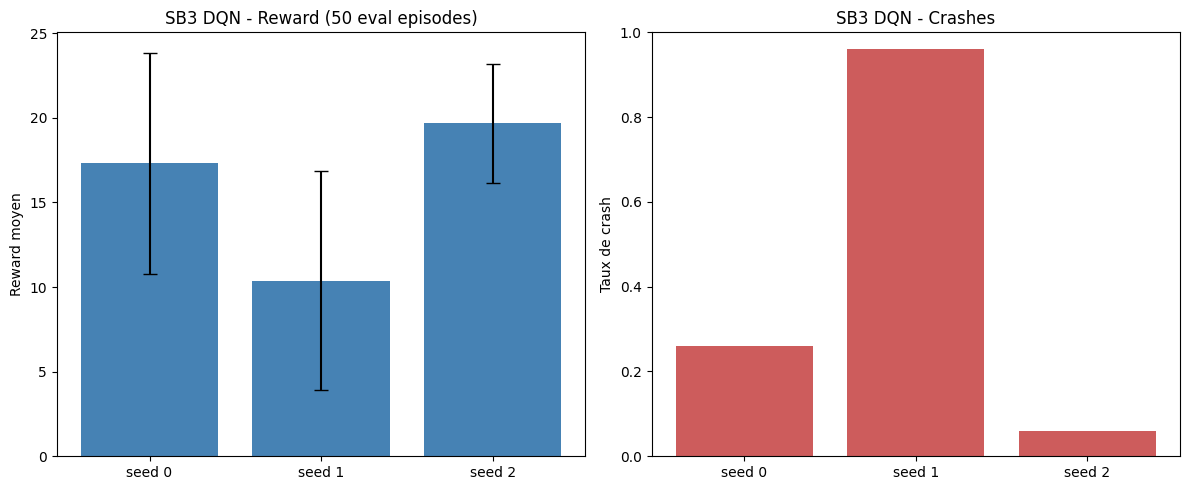

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

means = [eval_results[s]["mean_reward"] for s in SEEDS]
stds = [eval_results[s]["std_reward"] for s in SEEDS]
crash_rates = [eval_results[s]["crash_rate"] for s in SEEDS]

x = np.arange(len(SEEDS))
ax1.bar(x, means, yerr=stds, capsize=5, color="steelblue")
ax1.set_xticks(x)
ax1.set_xticklabels([f"seed {s}" for s in SEEDS])
ax1.set_ylabel("Reward moyen")
ax1.set_title("SB3 DQN - Reward (50 eval episodes)")

ax2.bar(x, crash_rates, color="indianred")
ax2.set_xticks(x)
ax2.set_xticklabels([f"seed {s}" for s in SEEDS])
ax2.set_ylabel("Taux de crash")
ax2.set_ylim(0, 1)
ax2.set_title("SB3 DQN - Crashes")

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "sb3_eval_results.png"), dpi=150)
plt.show()

## 08. Vidéo du meilleur seed

In [11]:
best_seed = SEEDS[int(np.argmax(means))]
best_model = trained_models[best_seed]

video_dir = os.path.join(SAVE_DIR, f"rollout_seed{best_seed}")
os.makedirs(video_dir, exist_ok=True)

env = gym.make(SHARED_CORE_ENV_ID, render_mode="rgb_array")
env.unwrapped.configure(SHARED_CORE_CONFIG)
env = gym.wrappers.RecordVideo(env, video_dir, episode_trigger=lambda e: e < 3)

for ep in range(3):
    obs, _ = env.reset(seed=best_seed + ep)
    done = False
    total_r = 0.0
    while not done:
        action, _ = best_model.predict(obs, deterministic=True)
        obs, r, terminated, truncated, _ = env.step(int(action))
        total_r += r
        done = terminated or truncated
    print(f"Episode {ep}: reward={total_r:.3f}")

env.close()
print(f"Videos saved -> {video_dir}")

c:\Users\JB\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\JB\Desktop\RL-project\checkpoints_sb\run_20260408-172848\rollout_seed2 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode 0: reward=20.572
Episode 1: reward=20.572
Episode 2: reward=20.455
Videos saved -> checkpoints_sb\run_20260408-172848\rollout_seed2


## 09. Analyse des echecs

In [12]:
def analyse_failures(model, n_episodes=100, seed_offset=9000):
    env = make_env(seed=seed_offset)
    crash_episodes = []

    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed_offset + i)
        done, total_r, steps = False, 0.0, 0
        actions = []

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            action = int(action)
            obs, r, terminated, truncated, info = env.step(action)
            total_r += r
            steps += 1
            actions.append(action)
            done = terminated or truncated

        if bool(info.get("crashed", False)):
            crash_episodes.append({
                "episode": i,
                "seed": seed_offset + i,
                "total_reward": float(total_r),
                "length": steps,
            })

    env.close()
    return crash_episodes


# Analyse sur le meilleur seed
best_model = trained_models[best_seed]
crashes = analyse_failures(best_model, n_episodes=FAILURE_EPISODES,
                           seed_offset=FAILURE_SEED_OFFSET)

crash_path = os.path.join(SAVE_DIR, "failure_summaries.json")
with open(crash_path, "w") as f:
    json.dump(crashes, f, indent=2)

print(f"Crashes: {len(crashes)}/{FAILURE_EPISODES} episodes ({len(crashes)/FAILURE_EPISODES:.0%})")
if crashes:
    crash_rewards = [c["total_reward"] for c in crashes]
    crash_lengths = [c["length"] for c in crashes]
    print(f"  Reward moyen au crash: {np.mean(crash_rewards):.2f} +/- {np.std(crash_rewards):.2f}")
    print(f"  Longueur moyenne: {np.mean(crash_lengths):.1f} +/- {np.std(crash_lengths):.1f}")
    print(f"  Crash le plus precoce: step {min(crash_lengths)}")
    print(f"  Crash le plus tardif: step {max(crash_lengths)}")
print(f"Saved -> {crash_path}")

Crashes: 9/100 episodes (9%)
  Reward moyen au crash: 12.99 +/- 4.11
  Longueur moyenne: 17.8 +/- 5.1
  Crash le plus precoce: step 7
  Crash le plus tardif: step 22
Saved -> checkpoints_sb\run_20260408-172848\failure_summaries.json


## 10. Comparaison avec DQN Custom
Charge les metriques du DQN custom (gamma=0.99) et produit des plots comparatifs.

In [13]:
# Charger les resultats du DQN custom (gamma=0.99)
import glob

custom_metrics_path = None
for p in glob.glob("checkpoints/run_*/gamma_0.99_metrics.json"):
    custom_metrics_path = p
    break

if custom_metrics_path is None:
    print("WARN: gamma_0.99_metrics.json non trouve, comparaison ignoree")
    custom_data = None
else:
    with open(custom_metrics_path) as f:
        custom_data = json.load(f)
    print(f"Custom DQN metrics loaded from {custom_metrics_path}")
    print(f"  Aggregate: reward={custom_data['aggregate']['mean_reward']:.2f} "
          f"+/- {custom_data['aggregate']['std_reward']:.2f}, "
          f"crash_rate={custom_data['aggregate']['crash_rate']:.2%}")

Custom DQN metrics loaded from checkpoints\run_20260331-155545\gamma_0.99_metrics.json
  Aggregate: reward=20.20 +/- 0.45, crash_rate=2.67%


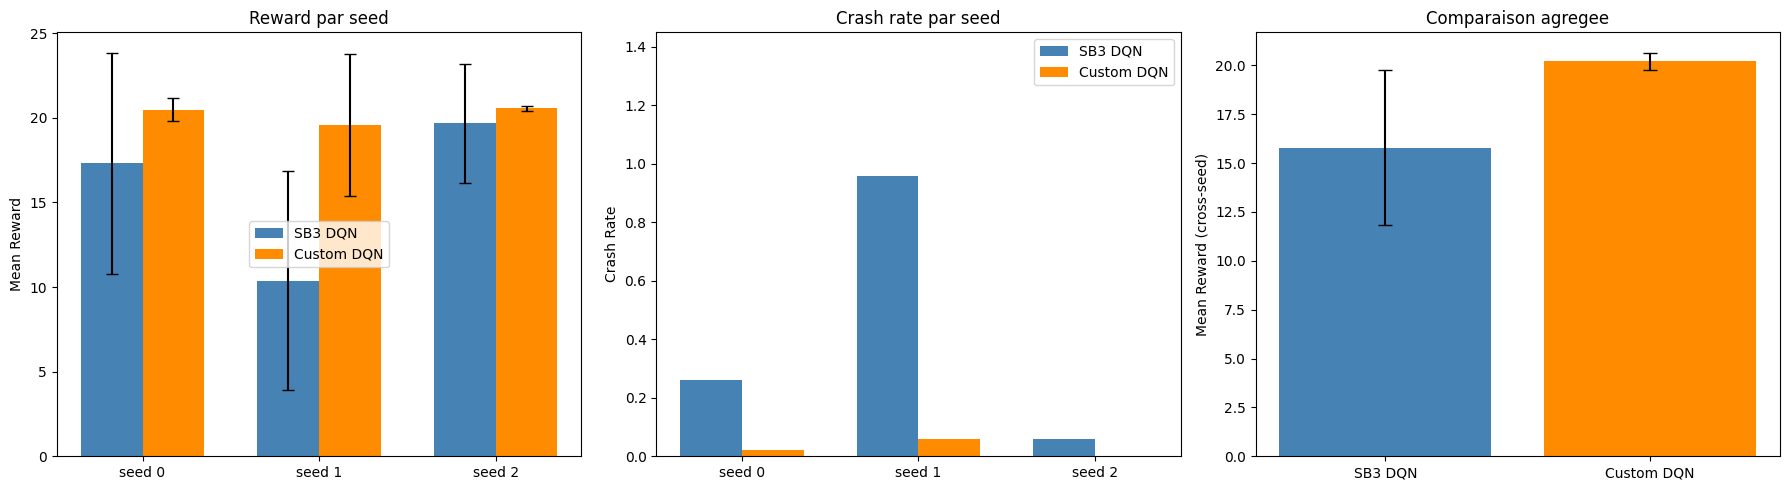

Saved -> checkpoints_sb\run_20260408-172848\comparison_eval.png


In [14]:
if custom_data is not None:
    # --- Bar chart comparatif: reward + crash rate ---
    sb3_agg = summary["aggregate"]
    cust_agg = custom_data["aggregate"]

    sb3_per_seed = {entry["seed"]: entry["eval"] for entry in summary["per_seed"]}
    cust_per_seed = {entry["seed"]: entry["eval"] for entry in custom_data["per_seed"]}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Reward par seed
    x = np.arange(len(SEEDS))
    w = 0.35
    sb3_means = [sb3_per_seed[s]["mean_reward"] for s in SEEDS]
    sb3_stds = [sb3_per_seed[s]["std_reward"] for s in SEEDS]
    cust_means = [cust_per_seed[s]["mean_reward"] for s in SEEDS]
    cust_stds = [cust_per_seed[s]["std_reward"] for s in SEEDS]

    axes[0].bar(x - w/2, sb3_means, w, yerr=sb3_stds, capsize=4,
                label="SB3 DQN", color="steelblue")
    axes[0].bar(x + w/2, cust_means, w, yerr=cust_stds, capsize=4,
                label="Custom DQN", color="darkorange")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f"seed {s}" for s in SEEDS])
    axes[0].set_ylabel("Mean Reward")
    axes[0].set_title("Reward par seed")
    axes[0].legend()

    # 2) Crash rate par seed
    sb3_cr = [sb3_per_seed[s]["crash_rate"] for s in SEEDS]
    cust_cr = [cust_per_seed[s]["crash_rate"] for s in SEEDS]

    axes[1].bar(x - w/2, sb3_cr, w, label="SB3 DQN", color="steelblue")
    axes[1].bar(x + w/2, cust_cr, w, label="Custom DQN", color="darkorange")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"seed {s}" for s in SEEDS])
    axes[1].set_ylabel("Crash Rate")
    axes[1].set_ylim(0, max(max(sb3_cr), max(cust_cr)) * 1.5 + 0.01)
    axes[1].set_title("Crash rate par seed")
    axes[1].legend()

    # 3) Aggregate
    labels = ["SB3 DQN", "Custom DQN"]
    agg_means = [sb3_agg["mean_reward"], cust_agg["mean_reward"]]
    agg_stds = [sb3_agg["std_reward"], cust_agg["std_reward"]]
    colors = ["steelblue", "darkorange"]

    axes[2].bar(labels, agg_means, yerr=agg_stds, capsize=5, color=colors)
    axes[2].set_ylabel("Mean Reward (cross-seed)")
    axes[2].set_title("Comparaison agregee")

    fig.tight_layout()
    fig.savefig(os.path.join(SAVE_DIR, "comparison_eval.png"), dpi=150)
    plt.show()
    print(f"Saved -> {os.path.join(SAVE_DIR, 'comparison_eval.png')}")

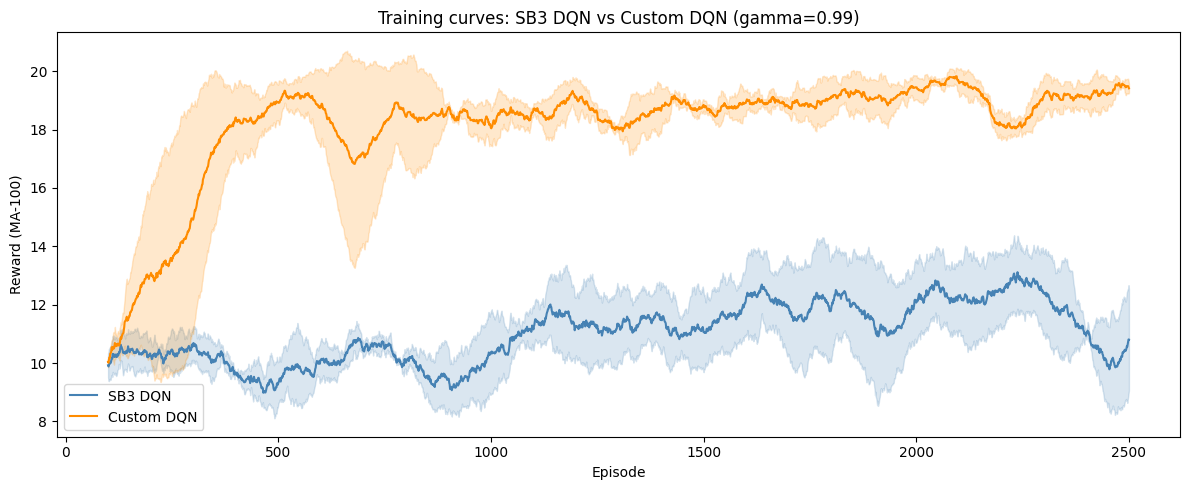

Saved -> checkpoints_sb\run_20260408-172848\comparison_training_curves.png


In [15]:
if custom_data is not None and "all_rewards" in custom_data:
    fig, ax = plt.subplots(figsize=(12, 5))

    sb3_rewards = [training_data[s]["rewards"] for s in SEEDS]
    cust_rewards = custom_data["all_rewards"]

    plot_multi_seed(sb3_rewards, label="SB3 DQN", ax=ax, color="steelblue")
    plot_multi_seed(cust_rewards, label="Custom DQN", ax=ax, color="darkorange")

    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward (MA-100)")
    ax.set_title("Training curves: SB3 DQN vs Custom DQN (gamma=0.99)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(SAVE_DIR, "comparison_training_curves.png"), dpi=150)
    plt.show()
    print(f"Saved -> {os.path.join(SAVE_DIR, 'comparison_training_curves.png')}")
elif custom_data is not None:
    print("all_rewards non disponible dans custom_data, skip training curves overlay")

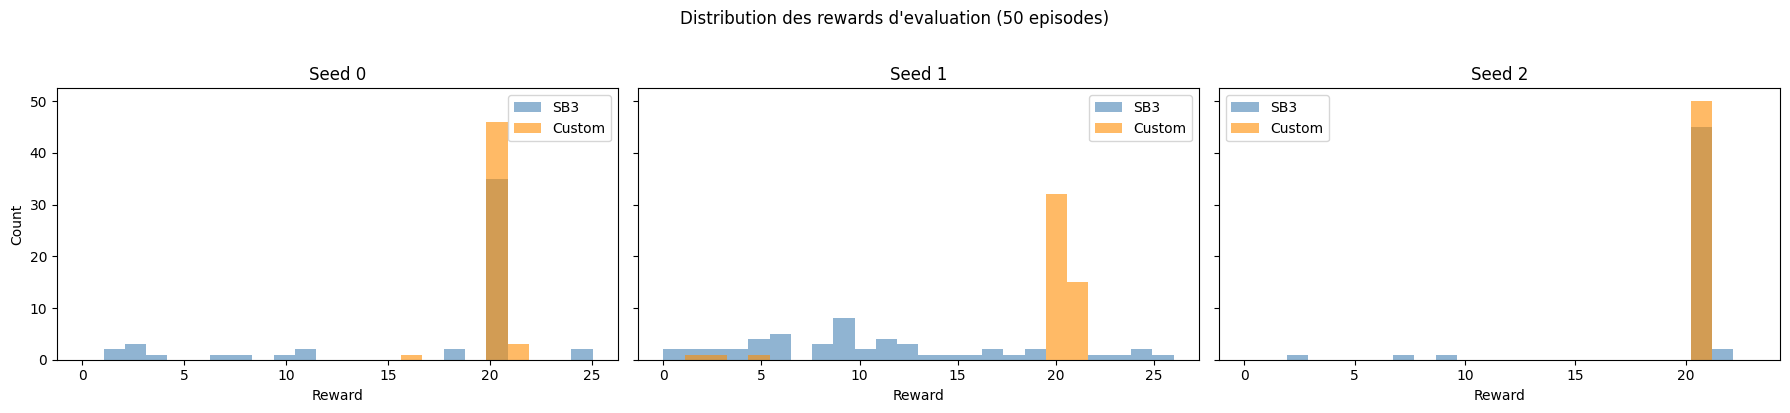

Saved -> checkpoints_sb\run_20260408-172848\comparison_reward_distribution.png


In [16]:
if custom_data is not None:
    # Distribution des rewards d'evaluation (histogramme)
    fig, axes = plt.subplots(1, len(SEEDS), figsize=(6 * len(SEEDS), 4), sharey=True)
    if len(SEEDS) == 1:
        axes = [axes]

    for ax, seed in zip(axes, SEEDS):
        sb3_raw = sb3_per_seed[seed]["raw_rewards"]
        cust_raw = cust_per_seed[seed]["raw_rewards"]

        bins = np.linspace(0, max(max(sb3_raw), max(cust_raw)) + 1, 25)
        ax.hist(sb3_raw, bins=bins, alpha=0.6, label="SB3", color="steelblue")
        ax.hist(cust_raw, bins=bins, alpha=0.6, label="Custom", color="darkorange")
        ax.set_title(f"Seed {seed}")
        ax.set_xlabel("Reward")
        ax.legend()

    axes[0].set_ylabel("Count")
    fig.suptitle("Distribution des rewards d'evaluation (50 episodes)", y=1.02)
    fig.tight_layout()
    fig.savefig(os.path.join(SAVE_DIR, "comparison_reward_distribution.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {os.path.join(SAVE_DIR, 'comparison_reward_distribution.png')}")

In [17]:
if custom_data is not None:
    print("=" * 70)
    print("  TABLEAU COMPARATIF FINAL")
    print("=" * 70)
    print(f"{'Metric':<25} {'SB3 DQN':>20} {'Custom DQN':>20}")
    print("-" * 70)

    sb3_a = summary["aggregate"]
    cust_a = custom_data["aggregate"]

    print(f"{'Mean reward':<25} {sb3_a['mean_reward']:>17.2f}    {cust_a['mean_reward']:>17.2f}")
    print(f"{'Std reward':<25} {sb3_a['std_reward']:>17.2f}    {cust_a['std_reward']:>17.2f}")
    print(f"{'Crash rate':<25} {sb3_a['crash_rate']:>16.2%}    {cust_a['crash_rate']:>16.2%}")
    print("-" * 70)

    for seed in SEEDS:
        sb3_s = sb3_per_seed[seed]
        cust_s = cust_per_seed[seed]
        print(f"  Seed {seed}:")
        print(f"    {'Reward':<21} {sb3_s['mean_reward']:>14.2f} +/- {sb3_s['std_reward']:<6.2f}"
              f"  {cust_s['mean_reward']:>8.2f} +/- {cust_s['std_reward']:<6.2f}")
        print(f"    {'Crash rate':<21} {sb3_s['crash_rate']:>14.0%}"
              f"          {cust_s['crash_rate']:>8.0%}")
        print(f"    {'Ep. length':<21} {sb3_s['mean_length']:>14.1f}"
              f"          {cust_s['mean_length']:>8.1f}")

    print("=" * 70)

  TABLEAU COMPARATIF FINAL
Metric                                 SB3 DQN           Custom DQN
----------------------------------------------------------------------
Mean reward                           15.79                20.20
Std reward                             3.95                 0.45
Crash rate                          42.67%               2.67%
----------------------------------------------------------------------
  Seed 0:
    Reward                         17.32 +/- 6.54       20.49 +/- 0.69  
    Crash rate                       26%                2%
    Ep. length                      24.9              29.9
  Seed 1:
    Reward                         10.37 +/- 6.47       19.57 +/- 4.21  
    Crash rate                       96%                6%
    Ep. length                      12.4              28.5
  Seed 2:
    Reward                         19.67 +/- 3.53       20.55 +/- 0.14  
    Crash rate                        6%                0%
    Ep. length            